#                                                                **Descriptive Analysis**

## ***Read the cleaned data set***

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nbformat

# Read merged file
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")
# Creating a copy of the data to work on, so the original data is not modified
df = hf_df.copy()

## ***Q1. What is the demographic profile of the hospitalized heart-failure population?***

#### *Reasoning : Patients belongs to each age group and how many are male or female. It also gives us a starting point for comparing other results, such as heart failure severity, across these groups.*

Age distribution:
age_category
21-29       4
29-39      12
39-49      56
49-59     106
59-69     368
69-79     715
79-89     646
89-110    101
Name: count, dtype: int64

Gender distribution:
gender
Female    1163
Male       845
Name: count, dtype: int64


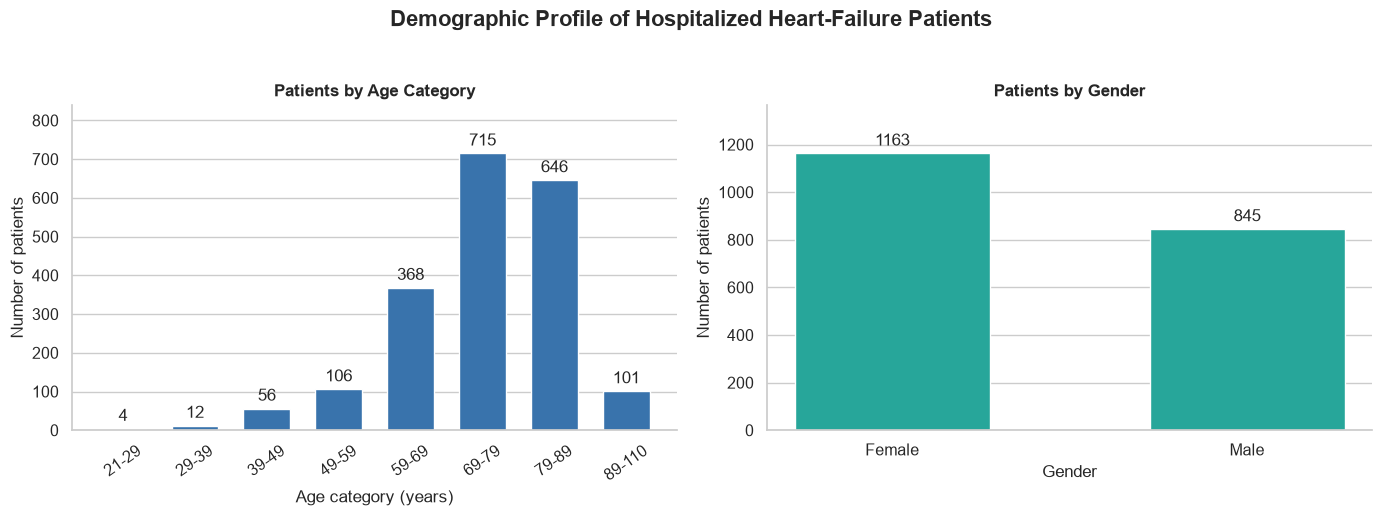

In [2]:

age_counts = df["age_category"].dropna().value_counts()
age_order = sorted(age_counts.index, key=lambda x: int(x.split("-")[0].strip()))
age_counts = age_counts.reindex(age_order)

gender_counts = df["gender"].dropna().value_counts()

print("Age distribution:")
print(age_counts)

print("\nGender distribution:")
print(gender_counts)

# Chart style
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Demographic Profile of Hospitalized Heart-Failure Patients",
    fontsize=16, fontweight="bold", y=1.03
)

# Age categories
age_bars = axes[0].bar(
    age_counts.index, age_counts.values,
    color="#3973AC", width=0.65
)
axes[0].set_title("Patients by Age Category", fontweight="bold")
axes[0].set_xlabel("Age category (years)")
axes[0].set_ylabel("Number of patients")
axes[0].tick_params(axis="x", rotation=35)
axes[0].bar_label(age_bars, padding=3)

# Gender
gender_bars = axes[1].bar(
    gender_counts.index, gender_counts.values,
    color="#27A69A", width=0.55
)
axes[1].set_title("Patients by Gender", fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Number of patients")
axes[1].bar_label(gender_bars, padding=3)

# Finishing touches
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

plt.tight_layout()
plt.show()

### ***Q2.What is the distribution of BMI among patients?***

#### *Reasoning: This shows the BMI values are common among the patients and whether some patients have much lower or higher BMI than most others.*

BMI summary statistics:
count    1969.00
mean       21.41
std         3.73
min        15.07
25%        18.67
50%        20.81
75%        23.44
max        39.11
Name: bmi, dtype: float64

BMI category distribution:
bmi
Underweight     476
Normal         1163
Overweight      263
Obese            61
Very Obese        6
Name: count, dtype: int64


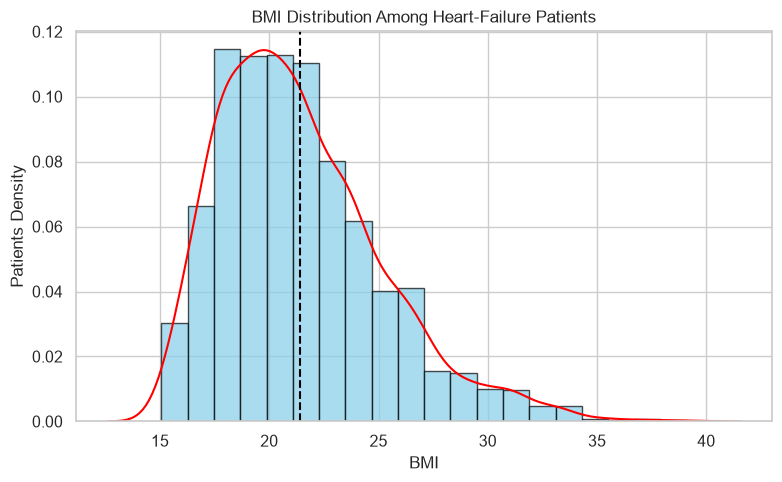

In [3]:

# BMI analysis
bmi_series = hf_df["bmi"].dropna()

# Summary statistics
print("BMI summary statistics:")
print(bmi_series.describe().round(2))

# BMI category breakdown
bmi_categories = pd.cut(
    bmi_series,
    bins=[0, 18.5, 24.9, 29.9, 34.9, float("inf")],
    labels=["Underweight", "Normal", "Overweight", "Obese", "Very Obese"]
)

category_counts = bmi_categories.value_counts().sort_index()
print("\nBMI category distribution:")
print(category_counts)

# Visualization
plt.figure(figsize=(8, 5))
plt.hist(bmi_series, bins=20, density=True, alpha=0.7, color="skyblue", edgecolor="black")
sns.kdeplot(bmi_series, color="red")
plt.axvline(bmi_series.mean(), color="black", linestyle="--", linewidth=1.5)

plt.title("BMI Distribution Among Heart-Failure Patients")
plt.xlabel("BMI")
plt.ylabel("Patients Density")
plt.tight_layout()
plt.show()

### ***Q3.Which existing health conditions are most common?***




#### *Reasoning: This helps us to see which health conditions patients already had and which ones appear most often in this group.*

mod_severe_ckd               23.6
diabetes                     23.2
copd                         11.6
cerebrovascular_disease       7.5
dementia                      5.7
liver_disease                 4.2
peptic_ulcer_disease          2.2
solid_tumor                   1.9
hemiplegia                    0.6
connective_tissue_disease     0.2
aids                          0.2
malignant_lymphoma            0.0
leukemia                      0.0
dtype: float64


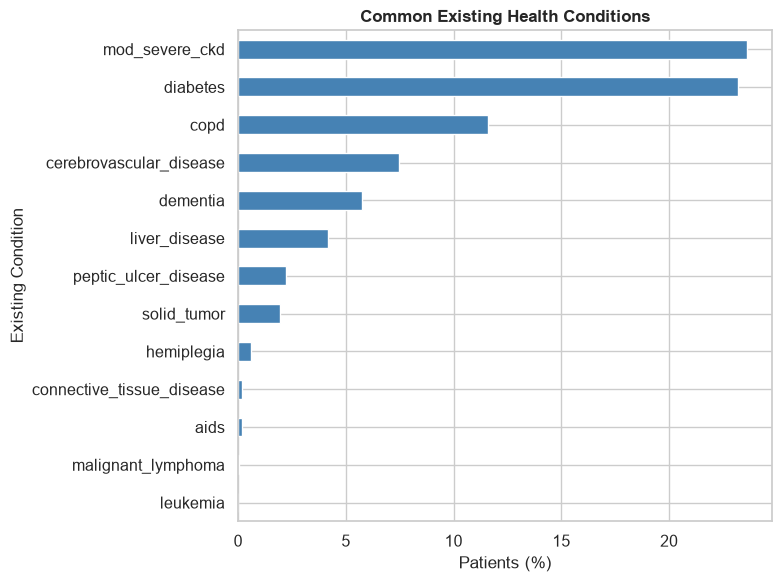

In [4]:
# Select comorbidity columns
conditions = [
    "cerebrovascular_disease", "dementia", "copd", "connective_tissue_disease",
    "peptic_ulcer_disease", "diabetes", "mod_severe_ckd", "hemiplegia",
    "leukemia", "malignant_lymphoma", "solid_tumor", "liver_disease", "aids"
]

cond_df = hf_df[conditions].fillna(0).astype(int)
percent = (cond_df.mean() * 100).sort_values(ascending=False)

print(percent.round(1))
plt.figure(figsize=(8, 6))
percent.plot(kind="barh", color="steelblue")
plt.title("Common Existing Health Conditions", fontsize=12, fontweight="bold")
plt.xlabel("Patients (%)")
plt.ylabel("Existing Condition")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



### ***Q4.How are patients distributed across heart failure types or severity categories?***

#### *Reasoning: This shows how many patients fall into each heart failure type or severity group. It helps us understand whether most patients have milder or more severe heart failure.*

heart_failure_type
both     1480
left      477
right      51
Name: count, dtype: int64


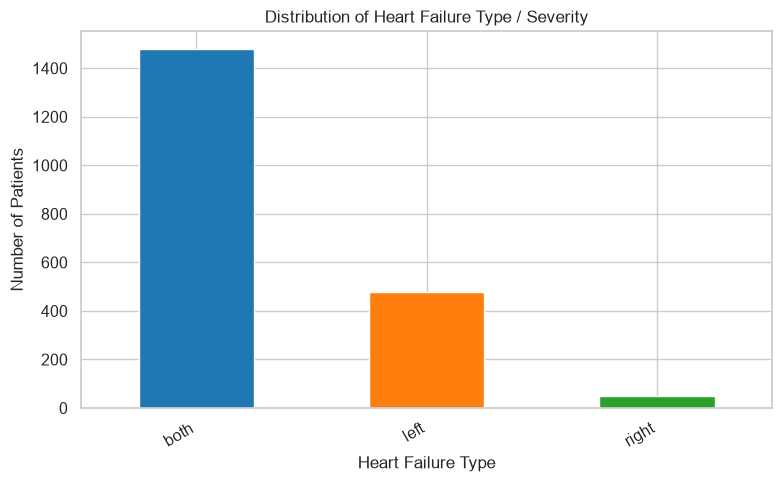

In [5]:



if "heart_failure_type" in hf_df.columns:
    severity_col = "heart_failure_type"
elif "nyha_cardiac_function_classification" in hf_df.columns:
    severity_col = "nyha_cardiac_function_classification"
elif "killip_grade" in hf_df.columns:
    severity_col = "killip_grade"
else:
    raise ValueError("No type/severity column found in the dataset.")

counts = hf_df[severity_col].dropna().astype(str).str.strip().value_counts()

print(counts)

# Bar chart with different colors
plt.figure(figsize=(8, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
          "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

counts.plot(kind="bar", color=colors[:len(counts)])
plt.title("Distribution of Heart Failure Type / Severity")
plt.xlabel(severity_col.replace("_", " ").title())
plt.ylabel("Number of Patients")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### ***Q5.Which cardiac complications are most common?***

#### *Reasoning : This helps us see which heart-related complications patients experienced most often*

congestive_heart_failure       93.2
myocardial_infarction           7.1
peripheral_vascular_disease     5.0
dtype: float64


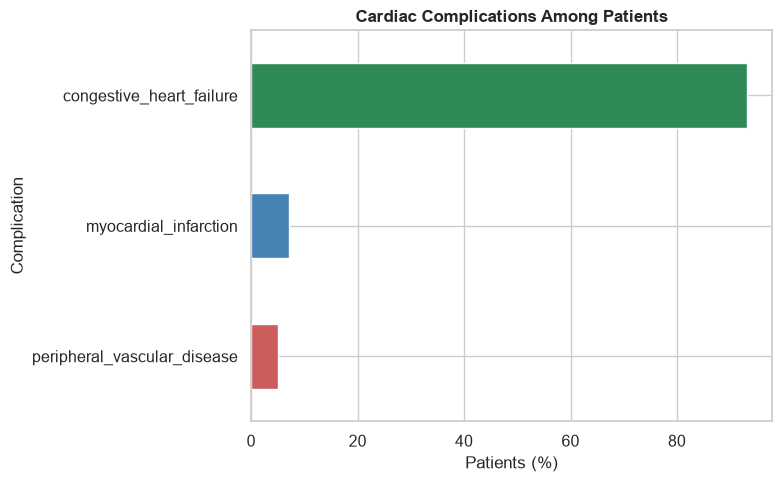

In [6]:
# Cardiac complication columns
complications = [
    "myocardial_infarction",
    "congestive_heart_failure",
    "peripheral_vascular_disease"
]

# Keep only relevant columns
comp_df = hf_df[complications].fillna(0).astype(int)

# Percentage of patients with each complication
percent = (comp_df.mean() * 100).sort_values(ascending=False)

print(percent.round(1))

# Horizontal bar chart
plt.figure(figsize=(8, 5))
percent.plot(kind="barh", color=["#2E8B57", "#4682B4", "#CD5C5C"])
plt.title("Cardiac Complications Among Patients", fontsize=12, fontweight="bold")
plt.xlabel("Patients (%)")
plt.ylabel("Complication")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### ***Q6.What is the distribution of key laboratory measurements?***

#### *Reasoning : This helps us understand the typical range and variability of key laboratory values in hospitalized heart-failure patients. It highlights whether most patients have normal or abnormal measurements, and shows extreme values that a simple average would hide.*

        sodium  potassium  hemoglobin
count  1974.00    1974.00     1974.00
mean    138.24       3.98      115.07
std       4.91       0.69       24.54
min     107.50       1.67       29.00
25%     136.00       3.52      101.00
50%     139.00       3.88      117.00
75%     141.30       4.33      131.00
max     159.00       7.29      200.00


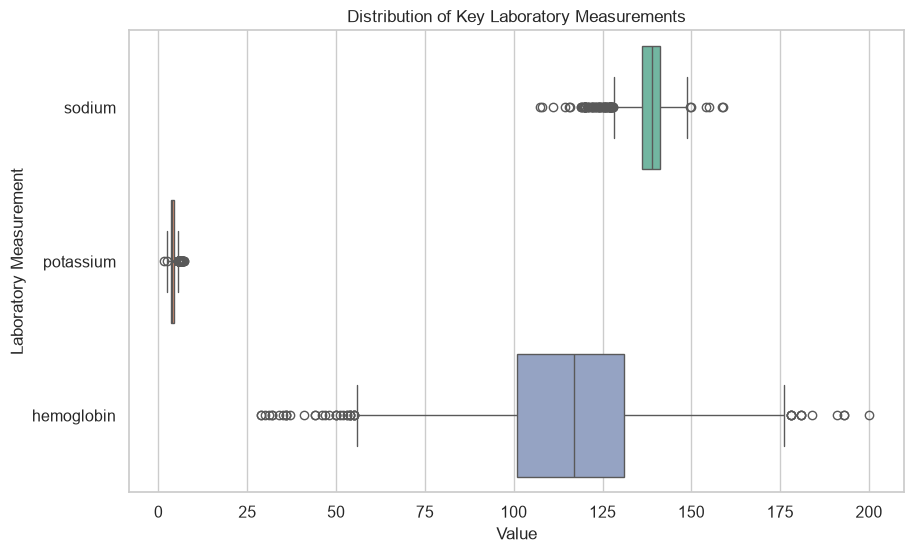

In [7]:
# Select key lab variables available in the dataset
lab_cols = ["sodium", "potassium", "hemoglobin"]
lab_cols = [c for c in lab_cols if c in hf_df.columns]

lab_df = hf_df[lab_cols].dropna()

# Summary stats
print(lab_df.describe().round(2))

# Boxplot for each lab measurement
plt.figure(figsize=(10, 6))
sns.boxplot(data=lab_df, orient="h", palette="Set2")
plt.title("Distribution of Key Laboratory Measurements")
plt.xlabel("Value")
plt.ylabel("Laboratory Measurement")
plt.show()

## **Q7.What are the blood pressure and heart rate patterns?**
##### *Reasoning: This code is used to explore and understand the distribution of important vital-sign variables. Focusing on these variables makes it easier to examine the patient's cardiovascular and respiratory status.*

               count        mean        std   min    25%    50%    75%    max
pulse         2007.0   85.277529  21.460326  32.0   70.0   82.0   98.0  198.0
systolic_bp   2003.0  131.289066  24.209600  50.0  113.0  130.0  147.0  252.0
diastolic_bp  2003.0   76.658013  14.136108  30.0   66.0   76.0   85.0  146.0
respiration   2007.0   19.095167   1.684902  15.0   18.0   19.0   19.0   36.0


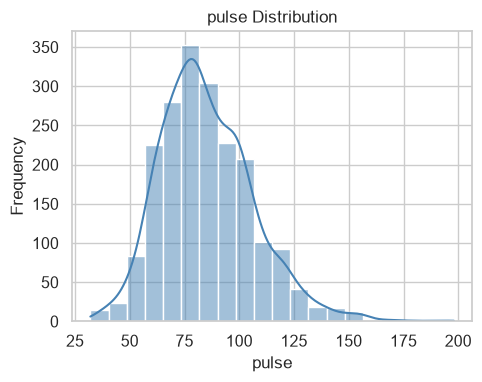

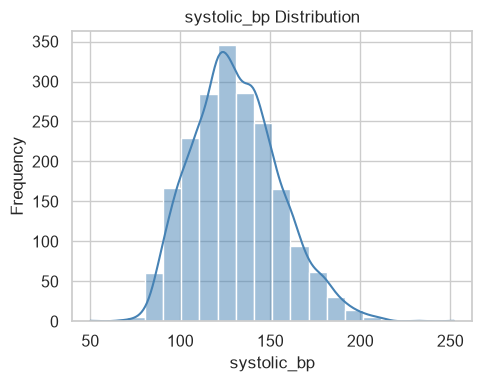

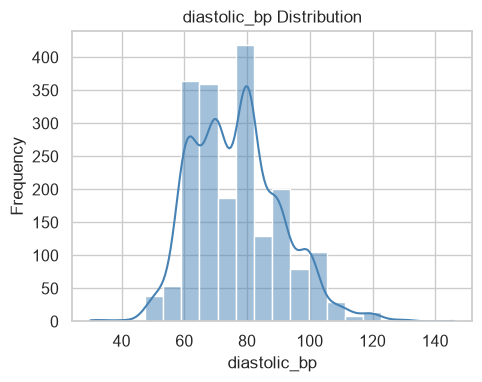

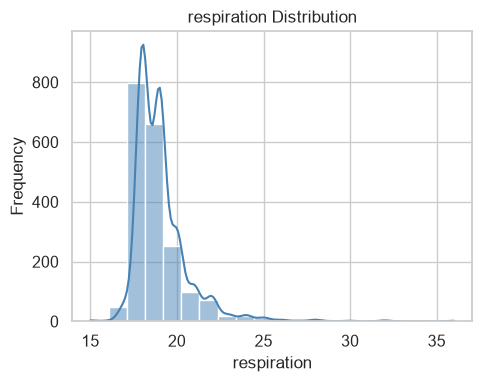

In [8]:

# Select key vital signs
vitals = ['pulse', 'systolic_bp', 'diastolic_bp', 'respiration']

# Show summary statistics
print(hf_df[vitals].describe().T)

# Separate histograms for each vital sign
for col in vitals:
    plt.figure(figsize=(5, 4))
    sns.histplot(hf_df[col].dropna(), bins=20, kde=True, color='steelblue')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


## ***Q8.What percentage of patients were readmitted at each recorded follow-up point?***
##### *Reasoning:This is to measure how often patients were readmitted at 28 days, 3 months, and 6 months, and compares those percentages across follow-up periods.*

In [9]:
# Follow-up columns
followup_cols = {
    "28 days": "readmission_28d",
    "3 months": "readmission_3mo",
    "6 months": "readmission_6mo"
}

# Calculate percentage readmitted at each follow-up point
summary = []
for label, col in followup_cols.items():
    series = hf_df[col].dropna()
    readmitted = int(series.sum())
    total = int(series.count())
    percent = (readmitted / total) * 100 if total else 0
    
    summary.append({
        "Follow-up": label,
        "Readmitted": readmitted,
        "Total Patients": total,
        "Percent (%)": percent
    })

result = pd.DataFrame(summary)
print(result)

  Follow-up  Readmitted  Total Patients  Percent (%)
0   28 days         140            2008     6.972112
1  3 months         498            2008    24.800797
2  6 months         773            2008    38.496016


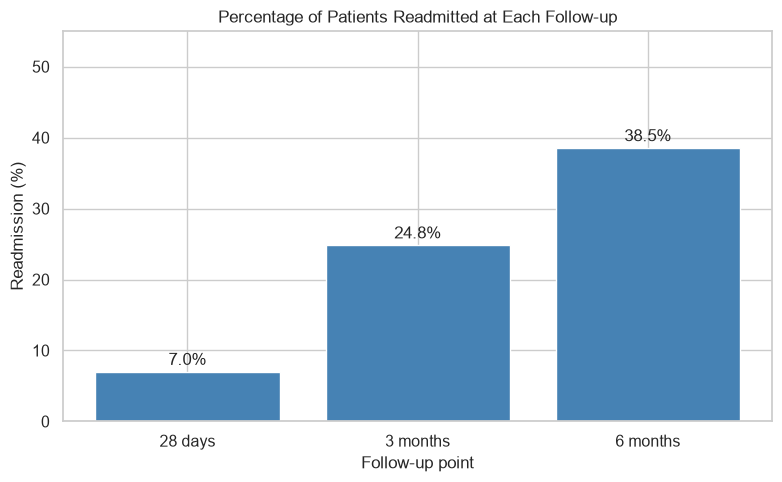

In [10]:
# bar chart
plt.figure(figsize=(8, 5))
plt.bar(result["Follow-up"], result["Percent (%)"], color="steelblue")
plt.title("Percentage of Patients Readmitted at Each Follow-up")
plt.xlabel("Follow-up point")
plt.ylabel("Readmission (%)")
plt.ylim(0, max(result["Percent (%)"]) * 1.3 + 5)
for i, v in enumerate(result["Percent (%)"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

 ## ***Q9. Which risk factors are more prevalent among patients who died?***

Reasoning: Compare proportions of anaemia, diabetes, smoking, and hypertension among deceased vs surviving patients. Useful visuals: Grouped bar charts.
Why it matters: Helps identify which comorbidities are more common in the high-risk group.




               risk_factor  died_count  survived_count
0                 diabetes          13             453
1                     copd           4             229
2           mod_severe_ckd          24             450
3  cerebrovascular_disease           6             144
4                 dementia           1             114


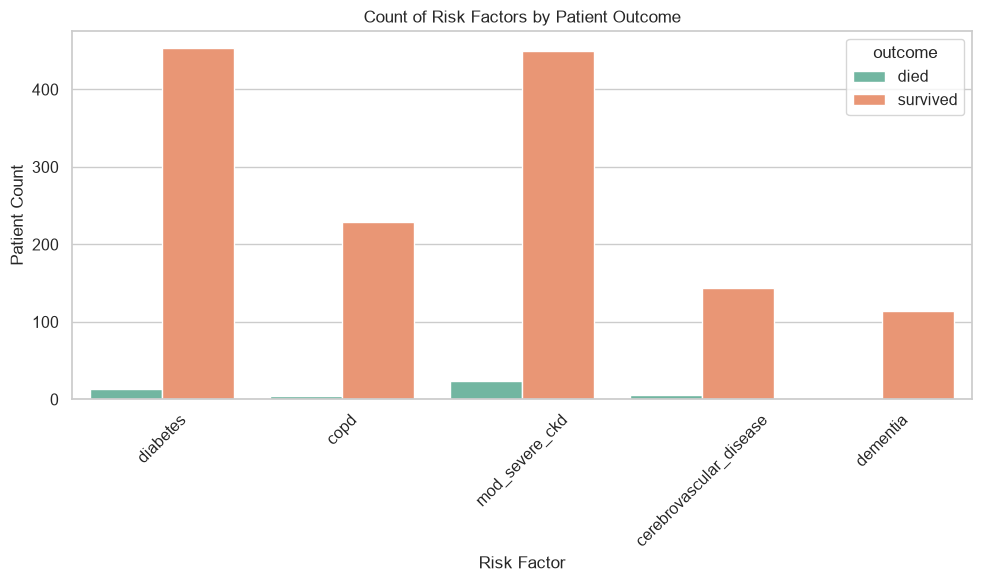

In [11]:

# 1) Define death outcome
df["died"] = (
    (df["in_hosp_outcome"].astype(str).str.lower() == "dead") |
    (df["mortality_28d"] == 1) |
    (df["death_3mo"] == 1) |
    (df["mortality_3mo"] == 1)
).astype(int)

# 2) Risk factors available in dataset
risk_factors = [
    "diabetes",
    "copd",
    "mod_severe_ckd",
    "cerebrovascular_disease",
    "dementia"
]

# Convert to binary counts: 0 = no, 1 = yes
for col in risk_factors:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df[col] = (df[col] > 0).astype(int)

# 3) Compare counts by outcome
comparison = []
for col in risk_factors:
    died_count = int(df.loc[df["died"] == 1, col].sum())
    survived_count = int(df.loc[df["died"] == 0, col].sum())

    comparison.append({
        "risk_factor": col,
        "died_count": died_count,
        "survived_count": survived_count
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df)

# 4) Prepare data for grouped bar chart
plot_df = comparison_df.melt(
    id_vars="risk_factor",
    value_vars=["died_count", "survived_count"],
    var_name="outcome",
    value_name="count"
)

plot_df["outcome"] = plot_df["outcome"].str.replace("_count", "", regex=False)

# 5) Plot grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="risk_factor", y="count", hue="outcome", palette="Set2")
plt.title("Count of Risk Factors by Patient Outcome")
plt.ylabel("Patient Count")
plt.xlabel("Risk Factor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ***Q12. What percentage of patients died at each recorded follow-up point?***
##### *Reasoning:*
##### *It is answered by comparing the proportion of patients who died at each recorded follow-up point, rather than simply counting deaths.The merged dataset contains time-specific survival indicators, including: in-hospital death, 28-day mortality, 3-month mortality*
##### *The approach we followed is:*
    1. convert each mortality indicator to a binary flag (0 = alive, 1 = dead)
    2. calculate the percentage dead at each follow-up point
    3. plot the percentages side by side to show how mortality rises or falls over time


C:\Users\aruns\AppData\Local\Temp\ipykernel_59536\2819243748.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hf_df["in_hospital_dead"] = hf_df["in_hosp_outcome"].apply(to_binary_dead)


     follow_up  deaths  total  mortality_pct
0  In hospital      11   1901       0.578643
1       28-day      37   2008       1.842629
2      3-month      57   2008       2.838645


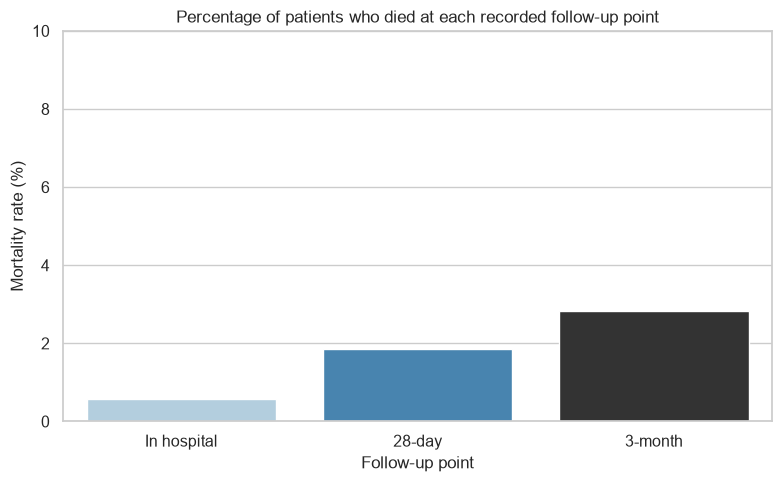

In [12]:
# identify the mortality columns available in the dataset
# these are the follow-up points we can compare
# in_hosp_outcome, mortality_28d, mortality_3mo

# clean the binary outcome columns
def to_binary_dead(value):
    if pd.isna(value):
        return pd.NA
    s = str(value).strip().lower()
    if s in ["dead", "death", "died", "1", "true", "yes"]:
        return 1
    elif s in ["alive", "0", "false", "no"]:
        return 0
    else:
        return pd.NA

hf_df["in_hospital_dead"] = hf_df["in_hosp_outcome"].apply(to_binary_dead)
hf_df["mortality_28d"] = pd.to_numeric(hf_df["mortality_28d"], errors="coerce")
hf_df["mortality_3mo"] = pd.to_numeric(hf_df["mortality_3mo"], errors="coerce")

# choose the recorded follow-up points for comparison
followup_map = {
    "In hospital": "in_hospital_dead",
    "28-day": "mortality_28d",
    "3-month": "mortality_3mo"
}

summary = []

for label, col in followup_map.items():
    s = hf_df[col].dropna()
    if s.empty:
        continue

    deaths = s.sum()
    total = len(s)
    pct = (deaths / total) * 100

    summary.append({
        "follow_up": label,
        "deaths": int(deaths),
        "total": int(total),
        "mortality_pct": pct
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=summary_df,
    x="follow_up",
    y="mortality_pct",
    hue=summary_df.index,
    dodge=False,
    legend=False,
    palette="Blues_d"
)

plt.title("Percentage of patients who died at each recorded follow-up point")
plt.xlabel("Follow-up point")
plt.ylabel("Mortality rate (%)")
plt.ylim(0, max(summary_df["mortality_pct"].max() * 1.3, 10))
plt.tight_layout()
plt.show()

### ***Q13.Which medications were prescribed most often?***




#### *Reasoning: Identifies the medications that occurred most frequently in the drugs_list column, helping to understand the most commonly prescribed treatment patterns among heart-failure patients.*

Top prescribed medications:
drugs_list
spironolactone tablet                               1833
furosemide injection                                1718
furosemide tablet                                   1641
meglumine adenosine cyclophosphate for injection    1114
deslanoside injection                               1015
digoxin tablet                                       998
aspirin enteric-coated tablet                        958
atorvastatin calcium tablet                          822
milrinone injection                                  707
sulfotanshinone sodium injection                     570
Name: count, dtype: int64


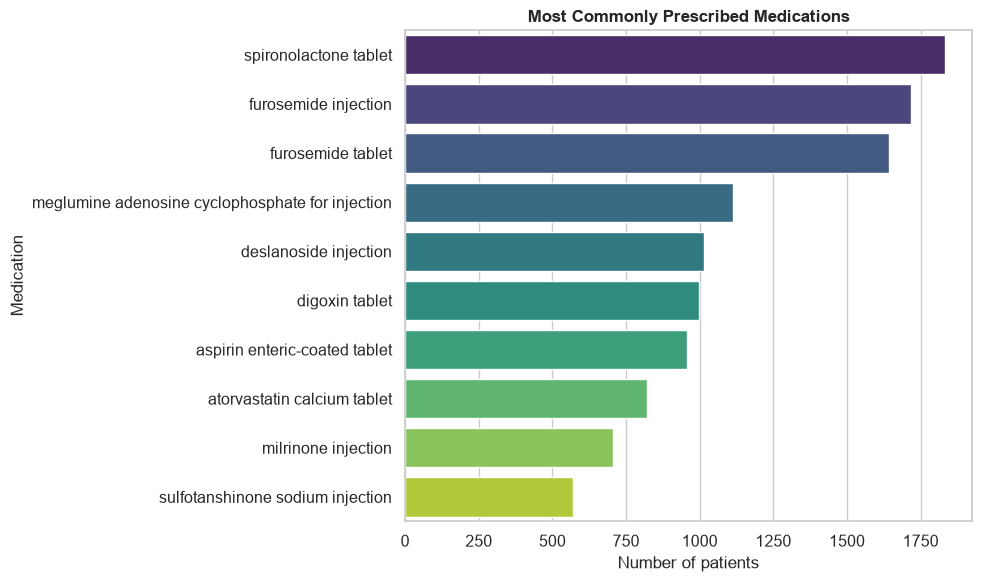

In [13]:
# Count individual medications from the drugs_list field
med_counts = (
    hf_df["drugs_list"]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
    .loc[lambda x: x != ""]
    .value_counts()
)

top_meds = med_counts.head(10)

print("Top prescribed medications:")
print(top_meds)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_meds.values,
    y=top_meds.index,
    hue=top_meds.index,
    palette="viridis",
    dodge=False,
    legend=False
)

plt.title("Most Commonly Prescribed Medications", fontsize=12, fontweight="bold")
plt.xlabel("Number of patients")
plt.ylabel("Medication")
plt.tight_layout()
plt.show()

## ***Q15. How does the recorded mortality rate vary by heart failure severity?***
##### *Reasoning: For this, I would use mortality_28d as the main outcome because it is a clear binary mortality indicator and is easier to compare across severity groups. As heart failure severity increases, mortality should rise, NYHA class or Killip grade is ordinal, therefore, the correct descriptive check is to compute mortality rate within each severity category and compare rates across categories*
##### *NYHA (Chronic heart Failure Severity) class I–IV describes functional severity of heart failure:*

        I: no limitation
        II: slight limitation
        III: marked limitation
        IV: symptoms even at rest
##### *For Killip Grade (Acute heart failure severity):*
        I: no heart failure
        II: mild/moderate heart failure
        III: pulmonary edema
        IV: cardiogenic shock


   nyha_class  patients  deaths  mortality_rate  mortality_rate_pct  \
0           2       353       3        0.008499            0.849858   
1           3      1039       7        0.006737            0.673725   
2           4       616      27        0.043831            4.383117   

  severity_label  
0        NYHA II  
1       NYHA III  
2        NYHA IV  


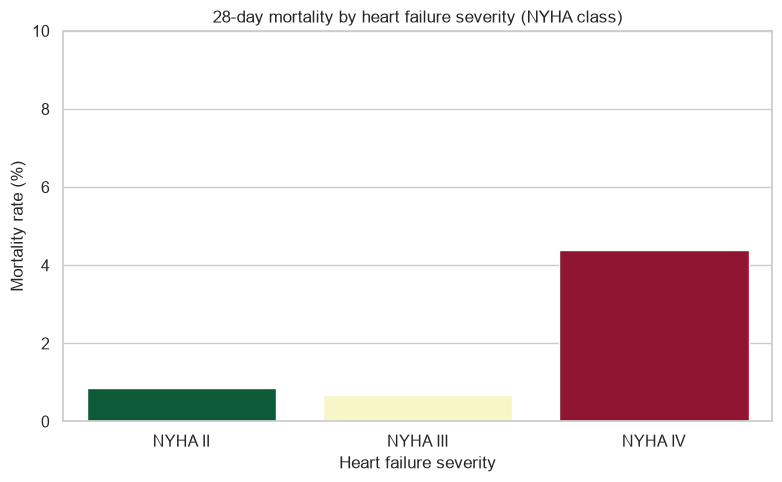

In [14]:
# Keep only needed columns
severity_df = hf_df[["patient_id", "nyha_cardiac_function_classification", "killip_grade", "mortality_28d", "in_hosp_outcome"]].copy()

# Clean severity columns
severity_df["nyha_class"] = pd.to_numeric(severity_df["nyha_cardiac_function_classification"], errors="coerce")
severity_df["killip"] = pd.to_numeric(severity_df["killip_grade"], errors="coerce")

# Clean outcome columns
severity_df["mortality_28d"] = pd.to_numeric(severity_df["mortality_28d"], errors="coerce").fillna(0)
severity_df["in_hospital_dead"] = severity_df["in_hosp_outcome"].astype(str).str.strip().str.lower().isin(["dead", "death", "died"])

# Remove missing severity values
severity_df = severity_df.dropna(subset=["nyha_class", "mortality_28d"])

# Summary by NYHA class
nyha_summary = (
    severity_df.groupby("nyha_class")
      .agg(
          patients=("patient_id", "count"),
          deaths=("mortality_28d", "sum"),
          mortality_rate=("mortality_28d", "mean")
      )
      .reset_index()
)

nyha_summary["mortality_rate_pct"] = nyha_summary["mortality_rate"] * 100
nyha_summary["severity_label"] = nyha_summary["nyha_class"].map({
    1: "NYHA I",
    2: "NYHA II",
    3: "NYHA III",
    4: "NYHA IV"
})

print(nyha_summary.sort_values("nyha_class"))

plt.figure(figsize=(8, 5))

sns.barplot(
    data=nyha_summary,
    x="severity_label",
    y="mortality_rate_pct",
    hue=nyha_summary.index,
    dodge=False,
    legend=False,
    palette="RdYlGn_r"
)

plt.title("28-day mortality by heart failure severity (NYHA class)")
plt.xlabel("Heart failure severity")
plt.ylabel("Mortality rate (%)")
plt.ylim(0, max(nyha_summary["mortality_rate_pct"].max() * 1.3, 10))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()